### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Multiple particles in a bounded domain, both BCs

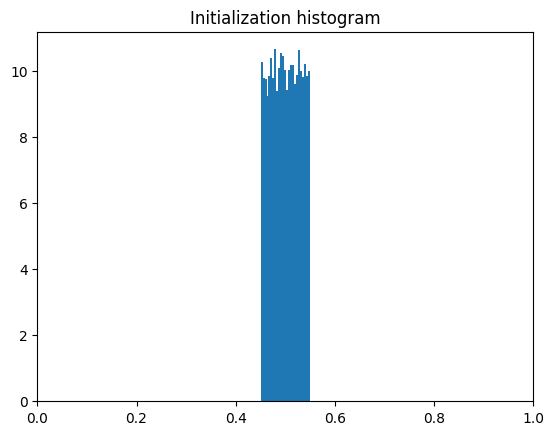

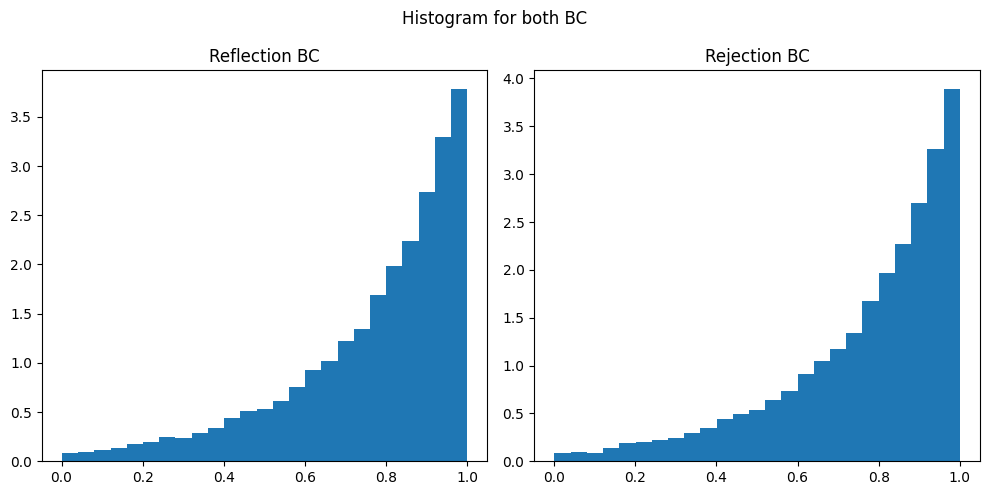

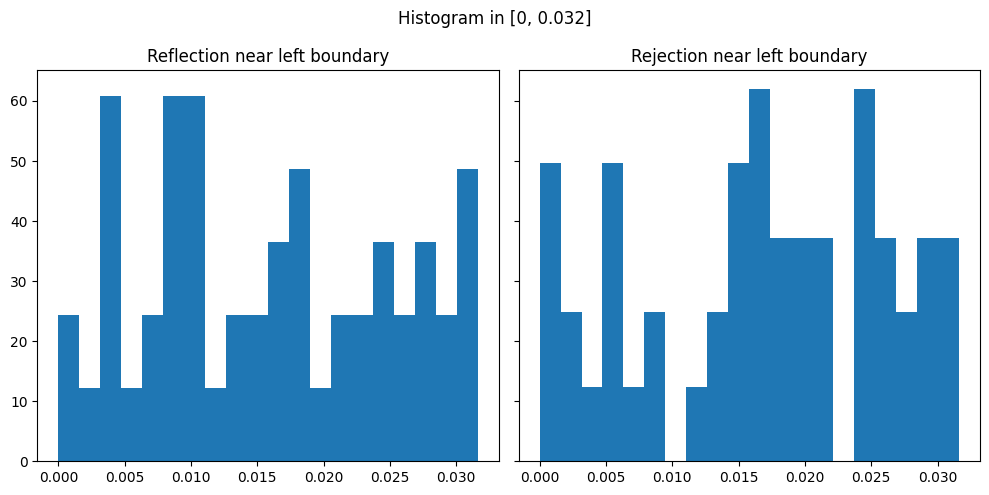

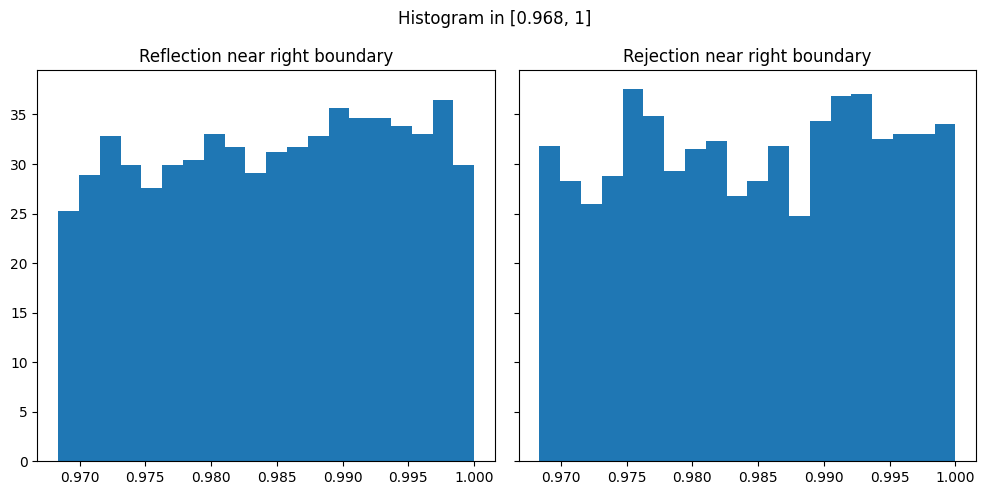

In [2]:

n_parts = 20000

#number of steps
T = 5
dt = 0.001
n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

# time = np.linspace(0, dt*n_steps, n_steps+1)
# time = np.zeros(n_steps+1)

#set the boundries 
bc_1 = 0
bc_2 = 1

#drift and diffusion coefficents
sigma  = 1
b = 2

# intial value
# X_0 = np.random.uniform(bc_1,bc_2, n_parts)
X_0 = np.random.uniform(.45,.55, n_parts)


# solution array with inital value
X_ref = np.zeros((n_steps+1, n_parts))
X_rej = np.zeros((n_steps+1, n_parts))

X_ref[0,:] = X_0
X_rej[0,:] = X_0

plt.hist(X_0, bins=25, density=True)
plt.title("Initialization histogram")
plt.xlim((bc_1, bc_2))
plt.show()

#precompute xi values
xi = np.random.normal(0,1, (n_steps,n_parts))

# this was just test for uniform instead of normal, same result as the theory
# xi = np.random.uniform(-1,1, (n_steps,n_parts)) 


# fig, ax = plt.subplots(1, 2, figsize=(10, 5))

#time step
for i in range(n_steps):
    X_ref[i+1,:] = X_ref[i,:] +  b* dt + epsilon*sigma* xi[i, :]
    
    #left boundry first then the right boundry
    X_ref[i+1, X_ref[i+1, :] < bc_1] = 2*bc_1 - X_ref[i+1, X_ref[i+1, :] < bc_1]
    X_ref[i+1, X_ref[i+1, :] > bc_2] = 2*bc_2 - X_ref[i+1, X_ref[i+1, :] > bc_2]

    
    #do the same but for rejection
    X_rej[i+1,:] = X_rej[i,:] +  b* dt + epsilon*sigma* xi[i, :]

    X_rej[i+1, X_rej[i+1, :] < bc_1] = X_rej[i, X_rej[i+1, :] < bc_1]
    X_rej[i+1, X_rej[i+1, :] > bc_2] = X_rej[i, X_rej[i+1, :] > bc_2]

    #this is taken from the code provided by SV
    #not working with subplots, need fixing later
    # if ((i+1) % 50 == 0):
    #     ax[0].cla()
    #     ax[1].cla()

    #     ax[0].set_title("Reflection BC")
    #     ax[0].hist(X_ref[i+1,:], bins=20, density=True)

    #     ax[1].set_title("Rejection BC")
    #     ax[1].hist(X_rej[i+1, :], bins=20, density=True)

    #     fig.suptitle(f"histogram change at {i}")
    #     plt.pause(1)

    
# plot full histogram
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


ax[0].set_title("Reflection BC")
ax[0].hist(X_ref[-1,:], bins=25, density=True)

ax[1].set_title("Rejection BC")
ax[1].hist(X_rej[-1, :], bins=25, density=True)


fig.suptitle("Histogram for both BC")
plt.tight_layout()
plt.show()



# inspect x in rand of width next to boundry
width = epsilon #0.1

bins = np.linspace(bc_1, bc_1 + width, 21)
X_ref_bl1 = X_ref[-1, X_ref[-1, :] <= bc_1 + width]
X_rej_bl1 = X_rej[-1, X_rej[-1, :] <= bc_1 + width]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].hist(X_ref_bl1, bins=bins, density=True)
ax[0].set_title("Reflection near left boundary")

ax[1].hist(X_rej_bl1, bins=bins, density=True)
ax[1].set_title("Rejection near left boundary")

fig.suptitle(f"Histogram in [{bc_1}, {bc_1+width:.3f}]")
plt.tight_layout()
plt.show()


bins = np.linspace(bc_2- width, bc_2, 21)
X_ref_bl2 = X_ref[-1, X_ref[-1, :] >= bc_2 - width]
X_rej_bl2 = X_rej[-1, X_rej[-1, :] >= bc_2 - width]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].hist(X_ref_bl2, bins=bins, density=True)
ax[0].set_title("Reflection near right boundary")

ax[1].hist(X_rej_bl2, bins=bins, density=True)
ax[1].set_title("Rejection near right boundary")

fig.suptitle(f"Histogram in [{bc_2-width:.3f}, {bc_2}]")
plt.tight_layout()
plt.show()
    
